# GKP-Based Quantum Error Correction in Photonic Systems
**Series:** GKP-QEC (S05)


## Interactive logical noise playground

This final demo is a sandbox for everything we built in S01 to S04. You choose a noise model, a noise strength p, a correction factor α, and the number of qubits. The circuit and measurement update when you rerun the cell; with widgets they update live.

Under the hood the circuit is simple: for 1 qubit we prepare |+⟩, for 2 qubits we prepare a Bell state, and for 3 qubits we prepare a GHZ state. We then apply the chosen logical noise channel to every qubit and measure an X-type observable (⟨X⟩, ⟨X⊗X⟩, or ⟨X⊗X⊗X⟩).

Correction is modeled as noise suppression: raw noise uses p, corrected noise uses α·p. This is not a physical GKP simulation, but it is a clean logical proxy for "correction makes the effective noise smaller."

In this notebook you can type values directly by editing the `simulate(...)` call. If `ipywidgets` is available, you may also see sliders. The desktop app provides the same controls with live plots and typed inputs (no sliders).


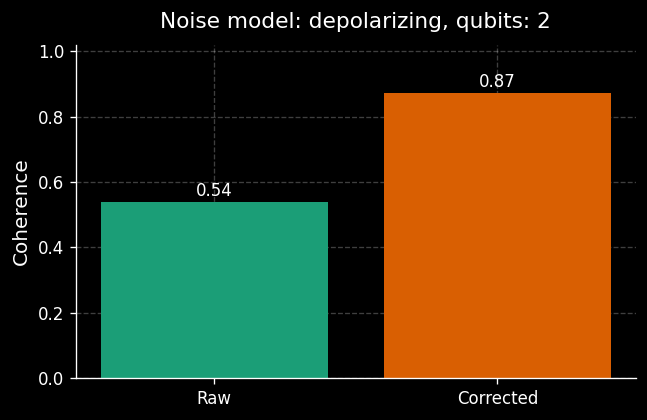

In [1]:
import os

# Ensure a writable Matplotlib cache and a safe backend for notebooks
os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")
os.environ.setdefault("IPYTHONDIR", "/tmp/ipython")

import matplotlib
try:
    from IPython import get_ipython

    if get_ipython() is not None:
        matplotlib.use("module://matplotlib_inline.backend_inline")
except Exception:
    pass

import numpy as np
import matplotlib.pyplot as plt
import pennylane as qml


def apply_plot_style():
    plt.rcParams.update(
        {
            "figure.dpi": 120,
            "savefig.dpi": 300,
            "axes.spines.top": False,
            "axes.spines.right": False,
            "axes.grid": True,
            "axes.axisbelow": True,
            "grid.alpha": 0.25,
            "grid.linestyle": "--",
            "axes.labelsize": 12,
            "axes.titlesize": 13,
            "axes.titlepad": 10,
            "legend.frameon": False,
            "legend.fontsize": 10,
            "lines.linewidth": 2.2,
            "lines.markersize": 4.5,
        }
    )


apply_plot_style()


def apply_noise(noise_model, p, wires):
    for w in wires:
        if noise_model == "depolarizing":
            qml.DepolarizingChannel(p, wires=w)
        elif noise_model == "bit_flip":
            qml.BitFlip(p, wires=w)
        elif noise_model == "phase_flip":
            qml.PhaseFlip(p, wires=w)
        elif noise_model == "amplitude_damping":
            qml.AmplitudeDamping(p, wires=w)
        elif noise_model == "phase_damping":
            qml.PhaseDamping(p, wires=w)
        else:
            raise ValueError(f"Unknown noise model: {noise_model}")


def make_circuit(n_qubits, noise_model):
    dev = qml.device("default.mixed", wires=n_qubits)

    @qml.qnode(dev)
    def circuit(p):
        if n_qubits == 1:
            qml.Hadamard(wires=0)
        elif n_qubits == 2:
            qml.Hadamard(wires=0)
            qml.CNOT(wires=[0, 1])
        else:
            qml.Hadamard(wires=0)
            qml.CNOT(wires=[0, 1])
            qml.CNOT(wires=[0, 2])

        apply_noise(noise_model, p, range(n_qubits))

        if n_qubits == 1:
            return qml.expval(qml.PauliX(0))
        elif n_qubits == 2:
            return qml.expval(qml.PauliX(0) @ qml.PauliX(1))
        else:
            return qml.expval(qml.PauliX(0) @ qml.PauliX(1) @ qml.PauliX(2))

    return circuit


def simulate(noise_model="depolarizing", p=0.2, alpha=0.25, n_qubits=2):
    circuit = make_circuit(n_qubits, noise_model)
    raw = circuit(p)
    corrected = circuit(alpha * p)

    fig, ax = plt.subplots(figsize=(5.5, 3.6))
    ax.bar(["Raw", "Corrected"], [raw, corrected], color=["#1b9e77", "#d95f02"])
    ax.set_ylim(0.0, 1.02)
    ax.set_ylabel("Coherence")
    ax.set_title(f"Noise model: {noise_model}, qubits: {n_qubits}")
    for i, val in enumerate([raw, corrected]):
        ax.text(i, val + 0.02, f"{val:.2f}", ha="center")
    fig.tight_layout()
    plt.show()


# Try to create interactive controls; fall back to a static example if unavailable
try:
    import ipywidgets as widgets
    from ipywidgets import interact

    interact(
        simulate,
        noise_model=widgets.Dropdown(
            options=[
                "depolarizing",
                "bit_flip",
                "phase_flip",
                "amplitude_damping",
                "phase_damping",
            ],
            value="depolarizing",
            description="Noise",
        ),
        p=widgets.FloatSlider(min=0.0, max=0.5, step=0.05, value=0.2, description="p"),
        alpha=widgets.FloatSlider(min=0.0, max=1.0, step=0.05, value=0.25, description="alpha"),
        n_qubits=widgets.Dropdown(options=[1, 2, 3], value=2, description="Qubits"),
    )
except Exception:
    simulate()


### What to try

Start with a baseline so you can calibrate your intuition. Set `noise_model="depolarizing"`, `p=0.2`, `alpha=0.25`, `n_qubits=1`. You should see the corrected bar higher than the raw bar.

Then try these small experiments, one at a time:

1. Hold p fixed and reduce alpha. The corrected bar should rise because you are suppressing noise more aggressively.
2. Hold alpha fixed and increase p. Both bars should fall, but the corrected bar should fall more slowly.
3. Switch to `phase_flip` and compare `n_qubits=1` vs `n_qubits=3`. The three-qubit coherence should collapse faster because it depends on all qubits staying coherent.
4. Try `amplitude_damping` and notice how it tends to pull states toward |0⟩, which changes the coherence in a different way than pure phase noise.

If you want a quick sanity check, set `alpha=1.0`. The corrected bar should match the raw bar exactly.


### Desktop playground (run locally)

Run the desktop playground from source:

```bash
pip install -r requirements.txt
cd pyqt_gui
python main.py
```

Optional packaging scripts are available in `pyqt_gui/` if you want to build distributable binaries.
